In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## TASK 1. Load and inspect dataset with Pandas.

### Dataset selection

Dataset from [World Development Indicators](https://databank.worldbank.org/source/world-development-indicators#) 

Dataset download [link](https://databank.worldbank.org/AjaxDownload/FileDownloadHandler.ashx?filename=P_884926e9-0b36-4ef9-9787-faa1ef592451.zip&filetype=CSV&language=en&displayfile=P_Data_Extract_From_World_Development_Indicators.zip)

Dataset file "884926e9-0b36-4ef9-9787-faa1ef592451_Data.csv" in archive extracted and renamed to "WDI_Data.csv" for easier identification

In [3]:
df=pd.read_csv("data/WDI_Data.csv")

In [4]:
df.head()

,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2005 [YR2005],2010 [YR2010],2015 [YR2015],2020 [YR2020]
0,Africa,(Africa),GDP (current US$),NY.GDP.MKTP.CD,..,..,..,..,..
1,Africa,(Africa),GDP per capita (current US$),NY.GDP.PCAP.CD,..,..,..,..,..
2,Africa,(Africa),GDP growth (annual %),NY.GDP.MKTP.KD.ZG,..,..,..,..,..
3,Africa,(Africa),Rural population,SP.RUR.TOTL,..,..,..,..,..
4,Africa,(Africa),Rural population growth (annual %),SP.RUR.TOTL.ZG,..,..,..,..,..


In [5]:
df.tail(20)

,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2005 [YR2005],2010 [YR2010],2015 [YR2015],2020 [YR2020]
1553,Togo,TGO,"Unemployment with advanced education, female (...",SL.UEM.ADVN.FE.ZS,..,..,..,12.064,..
1554,Togo,TGO,Unemployment with basic education (% of total ...,SL.UEM.BASC.ZS,..,..,..,..,..
1555,Togo,TGO,Unemployment with advanced education (% of tot...,SL.UEM.ADVN.ZS,..,..,..,8.227,..
1556,Togo,TGO,"Unemployment with advanced education, male (% ...",SL.UEM.ADVN.MA.ZS,..,..,..,7.013,..
1557,Togo,TGO,"Unemployment with basic education, female (% o...",SL.UEM.BASC.FE.ZS,..,..,..,..,..
1558,Togo,TGO,"Unemployment with basic education, male (% of ...",SL.UEM.BASC.MA.ZS,..,..,..,..,..
1559,Togo,TGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,..,..,..,2.204,..
1560,Togo,TGO,Unemployment with intermediate education (% of...,SL.UEM.INTM.ZS,..,..,..,1.878,..
1561,Togo,TGO,"Unemployment with intermediate education, fema...",SL.UEM.INTM.FE.ZS,..,..,..,1.899,..
1562,Togo,TGO,"Unemployment, female (% of female labor force)...",SL.UEM.TOTL.FE.ZS,4.11,4.094,2.102,1.687,2.047


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1573 entries, 0 to 1572
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   1570 non-null   object
 1   Country Code   1568 non-null   object
 2   Series Name    1568 non-null   object
 3   Series Code    1568 non-null   object
 4   2000 [YR2000]  1568 non-null   object
 5   2005 [YR2005]  1568 non-null   object
 6   2010 [YR2010]  1568 non-null   object
 7   2015 [YR2015]  1568 non-null   object
 8   2020 [YR2020]  1568 non-null   object
dtypes: object(9)
memory usage: 110.7+ KB


#### Rename columns for easier reference

In [7]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1573 entries, 0 to 1572
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   country_name   1570 non-null   object
 1   country_code   1568 non-null   object
 2   series_name    1568 non-null   object
 3   series_code    1568 non-null   object
 4   2000_[yr2000]  1568 non-null   object
 5   2005_[yr2005]  1568 non-null   object
 6   2010_[yr2010]  1568 non-null   object
 7   2015_[yr2015]  1568 non-null   object
 8   2020_[yr2020]  1568 non-null   object
dtypes: object(9)
memory usage: 110.7+ KB


In [9]:
df.columns = [col[:4] if col[:4].isdigit() else col for col in df.columns]

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1573 entries, 0 to 1572
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_name  1570 non-null   object
 1   country_code  1568 non-null   object
 2   series_name   1568 non-null   object
 3   series_code   1568 non-null   object
 4   2000          1568 non-null   object
 5   2005          1568 non-null   object
 6   2010          1568 non-null   object
 7   2015          1568 non-null   object
 8   2020          1568 non-null   object
dtypes: object(9)
memory usage: 110.7+ KB


#### Explore countries listed

In [11]:
df["country_name"].unique()

array(['Africa', 'Kenya', 'Ghana', 'Zambia', 'Zimbabwe', 'Tanzania',
       'Uganda', 'Nigeria', 'South Africa', 'Mozambique', 'Angola',
       'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde',
       'Cameroon', 'Central African Republic', 'Chad', 'Comoros',
       'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire",
       'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon',
       'Gambia, The', 'Guinea', 'Guinea-Bissau', 'Lesotho', 'Liberia',
       'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius',
       'Namibia', 'Niger', 'Rwanda', 'Sao Tome and Principe', 'Senegal',
       'Seychelles', 'Sierra Leone', 'Somalia', 'South Sudan', 'Sudan',
       'Togo', nan, 'Data from database: World Development Indicators',
       'Last Updated: 07/01/2025'], dtype=object)

##### Remove entries that are not valid

In [12]:
remove = ["Africa", "Data from database: World Development Indicators",
               "Last Updated: 07/01/2025"]

df = df[~df["country_name"].isin(remove)]

In [13]:
df["country_name"].unique()

array(['Kenya', 'Ghana', 'Zambia', 'Zimbabwe', 'Tanzania', 'Uganda',
       'Nigeria', 'South Africa', 'Mozambique', 'Angola', 'Benin',
       'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon',
       'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.',
       'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea',
       'Eswatini', 'Ethiopia', 'Gabon', 'Gambia, The', 'Guinea',
       'Guinea-Bissau', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi',
       'Mali', 'Mauritania', 'Mauritius', 'Namibia', 'Niger', 'Rwanda',
       'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone',
       'Somalia', 'South Sudan', 'Sudan', 'Togo', nan], dtype=object)

In [14]:
df = df[df["country_name"].notna()]

In [15]:
df["country_name"].unique()

array(['Kenya', 'Ghana', 'Zambia', 'Zimbabwe', 'Tanzania', 'Uganda',
       'Nigeria', 'South Africa', 'Mozambique', 'Angola', 'Benin',
       'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon',
       'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.',
       'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea',
       'Eswatini', 'Ethiopia', 'Gabon', 'Gambia, The', 'Guinea',
       'Guinea-Bissau', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi',
       'Mali', 'Mauritania', 'Mauritius', 'Namibia', 'Niger', 'Rwanda',
       'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone',
       'Somalia', 'South Sudan', 'Sudan', 'Togo'], dtype=object)

##### Rename Some countries for easier reference

In [16]:
rename_dict = {
    "Gambia, The": "Gambia",
    "Congo, Dem. Rep.": "Congo DR",
    "Congo, Rep.": "Congo Rep",
}

df["country_name"] = df["country_name"].replace(rename_dict)

df["country_name"].unique()

array(['Kenya', 'Ghana', 'Zambia', 'Zimbabwe', 'Tanzania', 'Uganda',
       'Nigeria', 'South Africa', 'Mozambique', 'Angola', 'Benin',
       'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon',
       'Central African Republic', 'Chad', 'Comoros', 'Congo DR',
       'Congo Rep', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea',
       'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Guinea',
       'Guinea-Bissau', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi',
       'Mali', 'Mauritania', 'Mauritius', 'Namibia', 'Niger', 'Rwanda',
       'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone',
       'Somalia', 'South Sudan', 'Sudan', 'Togo'], dtype=object)

#### Reshape the dataset from wide to long format so that each row represents a unique country–indicator–year combination.


In [17]:
# Identify ID columns and value columns
id_vars = ["country_name", "country_code", "series_name", "series_code"]  # columns to keep
value_vars = [col for col in df.columns if col.isdigit()]  # all year columns

# Melt the DataFrame to long/tidy format
df_tidy = df.melt(
    id_vars=id_vars,       # columns to keep
    value_vars=value_vars, # columns to unpivot
    var_name="year",       # name of new column for years
    value_name="value"     # name of new column for indicator values
)

# Convert year and value to numeric
df_tidy["year"] = df_tidy["year"].astype(int)                   # year as integer
df_tidy["value"] = pd.to_numeric(df_tidy["value"], errors="coerce")  # values as numeric

# Pivot to get one row per country-year, each indicator as a column
df_final = df_tidy.pivot_table(
    index=["country_name", "year"],   # unique rows
    columns="series_name",            # each indicator becomes a column
    values="value"                    # values go here
).reset_index()                       # make country_name and year regular columns

# view first few rows
df_final.head()


series_name,country_name,year,GDP (current US$),GDP growth (annual %),GDP per capita (current US$),"Inflation, GDP deflator (annual %)","Inflation, consumer prices (annual %)",Population living in slums (% of urban population),"Population, female","Population, female (% of total population)",...,"Unemployment with intermediate education, male (% of male labor force with intermediate education)","Unemployment, female (% of female labor force) (modeled ILO estimate)","Unemployment, female (% of female labor force) (national estimate)","Unemployment, male (% of male labor force) (modeled ILO estimate)","Unemployment, male (% of male labor force) (national estimate)","Unemployment, total (% of total labor force) (modeled ILO estimate)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %)
0,Angola,2000,9.129595e+09,3.054624,563.733796,418.018992,324.996872,19.70000,8239809.0,50.879133,...,NaN,18.669,NaN,14.664,NaN,16.682,NaN,8111524.0,50.087,5.716831
1,Angola,2005,3.697090e+10,15.030000,1916.468422,42.374249,22.953514,NaN,9805023.0,50.826505,...,NaN,18.314,NaN,14.371,NaN,16.360,NaN,10803050.0,56.000,5.763158
2,Angola,2010,8.379947e+10,4.398376,3597.342932,32.270469,14.469656,38.05496,11810187.0,50.698760,...,NaN,18.604,10.87,14.610,7.91,16.618,9.43,13926345.0,59.783,5.111876
3,Angola,2015,9.049642e+10,0.943572,3213.902611,-3.518385,9.355972,NaN,14252582.0,50.616822,...,NaN,17.528,NaN,15.464,NaN,16.490,NaN,17864997.0,63.446,4.738415
4,Angola,2020,4.850156e+10,-5.638215,1449.922867,10.763105,22.271539,62.60000,16911493.0,50.555818,...,NaN,16.614,NaN,16.764,NaN,16.690,NaN,22353719.0,66.825,4.242388


In [18]:
df_final.columns

Index(['country_name', 'year', 'GDP (current US$)', 'GDP growth (annual %)',
       'GDP per capita (current US$)', 'Inflation, GDP deflator (annual %)',
       'Inflation, consumer prices (annual %)',
       'Population living in slums (% of urban population)',
       'Population, female', 'Population, female (% of total population)',
       'Population, male', 'Population, male (% of total population)',
       'Population, total', 'Rural population',
       'Rural population (% of total population)',
       'Rural population growth (annual %)',
       'Unemployment with advanced education (% of total labor force with advanced education)',
       'Unemployment with advanced education, female (% of female labor force with advanced education)',
       'Unemployment with advanced education, male (% of male labor force with advanced education)',
       'Unemployment with basic education (% of total labor force with basic education)',
       'Unemployment with basic education, female (% of

### Drop irrelevant columns

**Columns Relevant to Task**

- country_name
- year
- GDP (current US$)
- GDP growth (annual%)
- GDP per capita (current US$) 
- Inflation, GDP deflator (annual %)
- Unemployment, total (% of total labor force) (modeled ILO estimate)
- Population, total


**Modeled ILO Estimate figures** selected to be used as opposed to national estimates because they:
- use a standard methodology.
- are designed to make cross-country comparisons possible.
- fill gaps where some countries have missing or inconsistent national data.
- are smoothed for anomalies, making trends more reliable for visualizations and analysis.

In [19]:
columns_to_keep = [
    "country_name",
    "year",
    "GDP (current US$)",
    "GDP growth (annual %)",
    "GDP per capita (current US$)",  # optional, but useful
    "Inflation, GDP deflator (annual %)",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)",
    "Population, total"
]

df_final = df_final[columns_to_keep]


In [20]:
# mapping original column names to cleaner names
rename_dict = {
    "country_name": "Country",
    "year": "Year",
    "GDP (current US$)": "GDP",
    "GDP growth (annual %)": "GDP_Growth",
    "GDP per capita (current US$)": "GDP_per_Capita",
    "Inflation, GDP deflator (annual %)": "Inflation",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)": "Unemployment",
    "Population, total": "Population"
}

df_final.rename(columns=rename_dict, inplace=True)

df_final.head()


series_name,Country,Year,GDP,GDP_Growth,GDP_per_Capita,Inflation,Unemployment,Population
0,Angola,2000,9.129595e+09,3.054624,563.733796,418.018992,16.682,16194869.0
1,Angola,2005,3.697090e+10,15.030000,1916.468422,42.374249,16.360,19291161.0
2,Angola,2010,8.379947e+10,4.398376,3597.342932,32.270469,16.618,23294825.0
3,Angola,2015,9.049642e+10,0.943572,3213.902611,-3.518385,16.490,28157798.0
4,Angola,2020,4.850156e+10,-5.638215,1449.922867,10.763105,16.690,33451132.0


## TASK 2. Handling Missing Values

### Checking which columns have missing values

In [21]:
df_final.isnull().sum()

series_name
Country           0
Year              0
GDP               5
GDP_Growth        5
GDP_per_Capita    5
Inflation         5
Unemployment      5
Population        0
dtype: int64

### Checking which countries have missing values.

In [22]:
df_final.groupby("Country")[["GDP", "GDP_Growth", "GDP_per_Capita", "Inflation", "Unemployment"]].apply(lambda x: x.isnull().sum())

series_name,GDP,GDP_Growth,GDP_per_Capita,Inflation,Unemployment
Country,,,,,
Angola,0,0,0,0,0
Benin,0,0,0,0,0
Botswana,0,0,0,0,0
Burkina Faso,0,0,0,0,0
Burundi,0,0,0,0,0
Cabo Verde,0,0,0,0,0
Cameroon,0,0,0,0,0
Central African Republic,0,0,0,0,0
Chad,0,0,0,0,0


### Missing Values by Country

Only three countries have missing data:
  - **Eritrea**: Missing GDP, GDP_Growth, GDP_per_Capita, and Inflation (2 missing each).
  - **South Sudan**: Missing GDP, GDP_Growth, GDP_per_Capita, and Inflation (3 missing each).
  - **Seychelles**: Missing all Unemployment data (5 missing).

**Interpretation:**
- The missing values are specific to a few countries, not random across the dataset.
- Likely due to incomplete economic reporting or data unavailability.

### Check if certain years are missing across countries

In [23]:
df_final.groupby("Year")[["GDP", "GDP_Growth", "GDP_per_Capita", "Inflation", "Unemployment"]].apply(lambda x: x.isnull().sum())

series_name,GDP,GDP_Growth,GDP_per_Capita,Inflation,Unemployment
Year,,,,,
2000,1,1,1,1,1
2005,1,1,1,1,1
2010,0,0,0,0,1
2015,1,1,1,1,1
2020,2,2,2,2,1


### Missing Values by Year

- Missing data occurs across multiple years:
  - Years **2000**, **2005**, **2015**, and **2020** each have 1–2 missing entries.
  - Year **2010** has only 1 missing value (unemployment).
- No year has missing data for all indicators or all countries.

**Interpretation:**
- The missingness is scattered over time, not concentrated in a single year.

### Check if any country has all values missing for an indicator

In [24]:
# Show only countries where ALL values are missing for any indicator
missing_entire_indicator = (
    df_final.groupby("Country")[["GDP", "GDP_Growth", "GDP_per_Capita", "Inflation", "Unemployment"]]
    .apply(lambda g: g.isnull().all())
)

# Filter to show only rows (countries) that have at least one True
missing_entire_indicator = missing_entire_indicator[missing_entire_indicator.any(axis=1)]

# Display the result

print(f"Countries with any completely missing indicators: {missing_entire_indicator.shape[0]}")

missing_entire_indicator

Countries with any completely missing indicators: 1


series_name,GDP,GDP_Growth,GDP_per_Capita,Inflation,Unemployment
Country,,,,,
Seychelles,False,False,False,False,True


### Countries with All Missing Data for an Indicator

- Only **Seychelles** has an entire indicator (Unemployment) missing for all years.
- All other countries have at least some data for each indicator.

***


### Final Interpretation of Missing Values

- Missing data is limited and follows a structured pattern (mostly for Eritrea, South Sudan, and Seychelles).
- Gaps occur in specific countries and years, not randomly across the dataset.
- The most suitable approach:
  - Use **interpolation** and **forward/backward fill** for countries with partial data.
  - Exclude Seychelles’ unemployment data from analysis, as it lacks any valid points to estimate from.
  - This ensures the dataset remains complete and logically consistent without introducing artificial distortions.

***


### Handling Missing Values

Economic indicators like GDP, inflation, and unemployment typically change gradually over time.  
Interpolation and forward/backward fill are used to estimate missing values logically.

- Interpolation estimates values between known data points (e.g., between 2010 and 2015, if 2005 is missing).  
- Forward fill (ffill) and backward fill (bfill) handle missing values at the start or end of the series.  
- This approach preserves smooth economic trends across years without introducing distortions.

### Handling Seychelles Unemployment

- Seychelles has no unemployment data for any year in the dataset.
- These missing values are **intentionally left as null (NaN)**.
- For analyses or visualizations involving unemployment, Seychelles will be excluded or treated as missing.
- All other indicators (GDP, Inflation, Population) for Seychelles will  fully included.

In [25]:
# 1) Columns to process
cols = ["GDP", "GDP_Growth", "GDP_per_Capita", "Inflation", "Unemployment"]

# 2) Work on a copy so original df_final remains intact to go back to in case of errors
df_final_clean = df_final.copy()

# 3) Ensure rows are sorted by Country then Year
df_final_clean = df_final_clean.sort_values(["Country", "Year"]).reset_index(drop=True)

# 4) Interpolate within each country (linear). Use transform for safe alignment.
df_final_clean[cols] = (
    df_final_clean.groupby("Country")[cols]
    .transform(lambda s: s.interpolate(method="linear"))
)

# 5) Fill remaining edge NaNs per country: forward-fill then backward-fill
df_final_clean[cols] = (
    df_final_clean.groupby("Country")[cols]
    .transform(lambda s: s.ffill().bfill())
)

# 6) Quick checks
print("Missing after cleaning:")
print(df_final_clean[cols].isnull().sum())


Missing after cleaning:
series_name
GDP               0
GDP_Growth        0
GDP_per_Capita    0
Inflation         0
Unemployment      5
dtype: int64


### Save the fully cleaned dataset to CSV

In [26]:
df_final_clean.to_csv("africa_WDI_clean.csv", index=False)


## Task 3. Descriptive Statistics

In [27]:
df_final_clean.describe()

series_name,Year,GDP,GDP_Growth,GDP_per_Capita,Inflation,Unemployment,Population
count,240.000000,2.400000e+02,240.000000,240.000000,240.000000,235.000000,2.400000e+02
mean,2010.000000,2.559547e+10,3.192047,1830.960752,23.466666,8.455494,1.895718e+07
std,7.085845,6.694226e+10,5.573765,2553.744715,175.828861,6.968579,2.952157e+07
min,2000.000000,7.619839e+07,-20.805276,122.269203,-22.932319,0.553000,8.113100e+04
25%,2005.000000,2.543283e+09,0.873399,482.154129,1.634502,3.184000,2.244205e+06
50%,2010.000000,8.642143e+09,3.746878,849.780567,5.457242,5.384000,1.052016e+07
75%,2015.000000,1.579539e+10,6.141521,1682.424392,12.327017,12.716500,2.153748e+07
max,2020.000000,4.930267e+11,28.615934,15333.105173,2630.122674,32.944000,2.139962e+08


**Summary Statistics**

- Descriptive statistics show the data is now clean and mostly complete (235–240 valid values).
- Effect of unavailability of Seychelles’ unemployment data: unemployment has 235 valid observations as opposed to 240 valid observations for all other variables.
- Large variation in GDP, population, and inflation reflects major cross-country differences.
- Dataset is ready for visualization and further analysis.

### Interpretation:

#### Mean
- GDP: Average total output = $25.6 billion, but varies widely across countries.
- GDP_Growth: Average growth rate = 3.19%, showing moderate annual expansion.
- GDP_per_Capita: Average = $1,831, suggesting most countries are low to lower-middle income.
- Inflation: Average = 23.47%, which looks high because a few countries experienced extreme inflation.
- Unemployment: Average = 8.46%, moderate, but hides large variation.
- Population: Average = 18.96 million.

#### Standard Deviation
- GDP and Population show very huge differences between small and large economies (e.g., Seychelles vs. Nigeria).
- Inflation std = 175.83 → very volatile inflation across countries and years.

#### Min
- GDP: $76 million — very small economy (e.g., a small island state).
- GDP_Growth: -20.8% — shows sharp decline in economic output for a country (possibly crisis year).
- Inflation: -22.9% — negative inflation period for some country/year, prices fell drastically.
- Unemployment: 0.55% — almost full employment case, reflects very low unemployment.
- Population: 81,131 — smallest country (likely Seychelles or similar).

#### 50% (Median)
Half of the countries fall below and half above these values. 
- Median GDP: $8.64 billion — typical mid-sized developing economy, comparable to nations like Ghana or Kenya.
- Median GDP Growth: 3.7% — steady, sustainable, healthy expansion rate (normal range ≈ 2–5%).
- Median Inflation: 5.46% — moderate and reasonable inflation for most, stable price growth (normal range ≈ 2–6%).
- Median Unemployment: 5.38% — reflects near full employment (normal range ≈ 4–6%).

#### Max
- GDP: $493 billion — most likely South Africa or Nigeria.
- Inflation: 2630% — hyperinflation year in one country (most likely Zimbabwe).
- Unemployment: 32.9% — severe unemployment in at least one observation.
	


### Benchmarks used are listed below

| **Indicator**      | **Common Benchmark Range**         | **Source/Reference Context**                                                                               |
| ------------------ | ---------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| **GDP Growth**     | 2–5% per year (sustainable growth) | World Bank, IMF, OECD — derived from long-term global averages.                                            |
| **Inflation**      | 2–6% (moderate inflation)          | Central bank targets (e.g., IMF recommends <10%; many central banks target ≈2–3%).                         |
| **Unemployment**   | 4–6% (full employment)             | OECD, ILO — considers frictional and structural unemployment normal.                                       |
| **GDP per Capita** | Context-dependent                  | World Bank income classification thresholds (e.g., low-income < $1,135; lower-middle $1,136–$4,465, etc.). |

***

## Task 4. Visualisations

### a. GDP Growth Over Time For 3 Countries

### Set 1:
three countries that illustrate different economic situations.
- Nigeria – large, oil-driven economy
- Kenya – diversified and service-led
- South Africa – industrial and relatively advanced

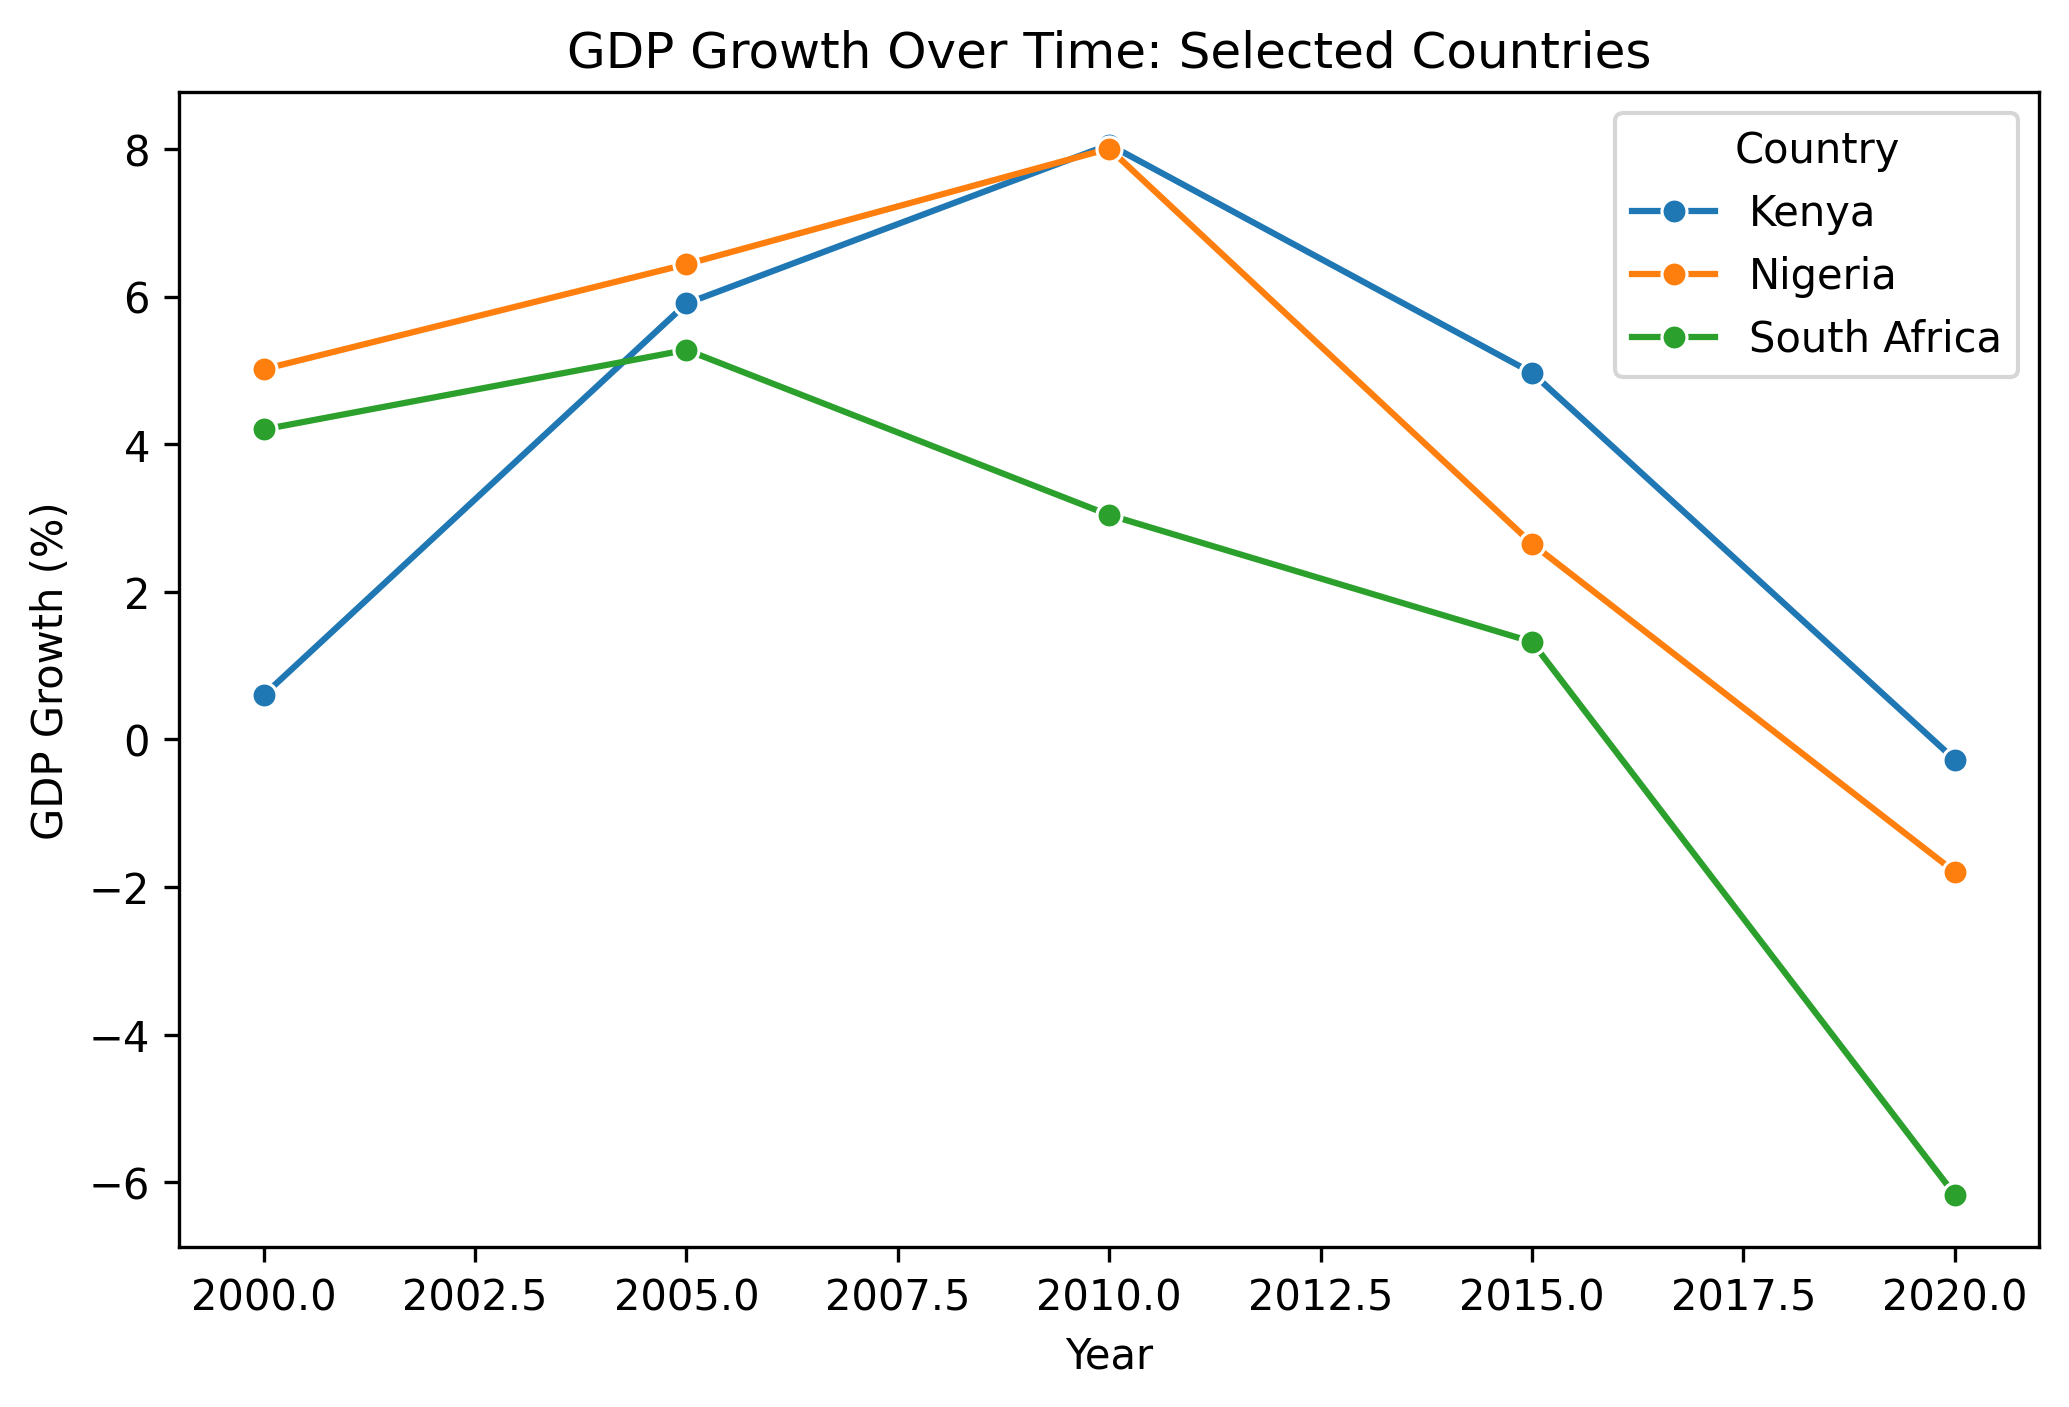

In [28]:
# Set 1
countries_set1 = ["Nigeria", "Kenya", "South Africa"]
df_set1 = df_final_clean[df_final_clean["Country"].isin(countries_set1)]

# Plot Set 1
plt.figure(figsize=(8,5), dpi=300)
sns.lineplot(data=df_set1, x="Year", y="GDP_Growth", hue="Country", marker="o")
plt.title("GDP Growth Over Time: Selected Countries")
plt.ylabel("GDP Growth (%)")
plt.savefig("gdp_growth.png", bbox_inches="tight")
plt.show()

**Key Insights:**

- All three countries show significant volatility in GDP growth between 2000-2020
- The 2020 pandemic caused synchronized negative growth across all three economies
- Kenya demonstrates relatively more stable growth, peaking in 2010 and then declining steadily
- Nigeria exhibits the most drastic fluctuation, with a steady decline between 2010 and 2020 (likely related to oil price crashes and the 2020 COVID-19 impact)
- South Africa shows declining growth momentum over the entire period, with only slight improvement between 2000 and 2005, suggesting structural economic challenges


### b. Inflation Trends Compared Across Regions

### African Development Bank (AfDB) regions

In [29]:
# African Development Bank (AfDB) regions
region_map = {
    # Central Africa
    "Benin": "Central Africa", "Burundi": "Central Africa", "Central African Republic": "Central Africa",
    "Chad": "Central Africa", "DR Congo": "Central Africa", "Comoros": "Central Africa",
    "Djibouti": "Central Africa", "Gabon": "Central Africa",
    
    # East Africa
    "Eritrea": "East Africa", "Ethiopia": "East Africa", "Kenya": "East Africa",
    "Rwanda": "East Africa", "Somalia": "East Africa", "South Sudan": "East Africa",
    "Sudan": "East Africa", "Tanzania": "East Africa", "Uganda": "East Africa",
    
    # North Africa
    "Algeria": "North Africa", "Egypt": "North Africa", "Libya": "North Africa",
    "Mauritania": "North Africa", "Morocco": "North Africa", "Tunisia": "North Africa",
    
    # Southern Africa
    "Angola": "Southern Africa", "Botswana": "Southern Africa", "Eswatini": "Southern Africa",
    "Lesotho": "Southern Africa", "Madagascar": "Southern Africa", "Malawi": "Southern Africa",
    "Mauritius": "Southern Africa", "Mozambique": "Southern Africa", "Namibia": "Southern Africa",
    "South Africa": "Southern Africa", "Zambia": "Southern Africa", "Zimbabwe": "Southern Africa",
    
    # West Africa
    "Burkina Faso": "West Africa", "Cape Verde": "West Africa", "Gambia": "West Africa",
    "Ghana": "West Africa", "Guinea": "West Africa", "Guinea-Bissau": "West Africa",
    "Ivory Coast": "West Africa", "Liberia": "West Africa", "Mali": "West Africa",
    "Niger": "West Africa", "Nigeria": "West Africa", "Senegal": "West Africa",
    "Sierra Leone": "West Africa", "Togo": "West Africa", "Sao Tome and Principe": "West Africa"
}


In [30]:
# Add region column to cleaned dataset:
df_final_clean["Region"] = df_final_clean["Country"].map(region_map)

# Calculate average inflation per region over years:
inflation_region = df_final_clean.groupby(["Region", "Year"])["Inflation"].mean().reset_index()

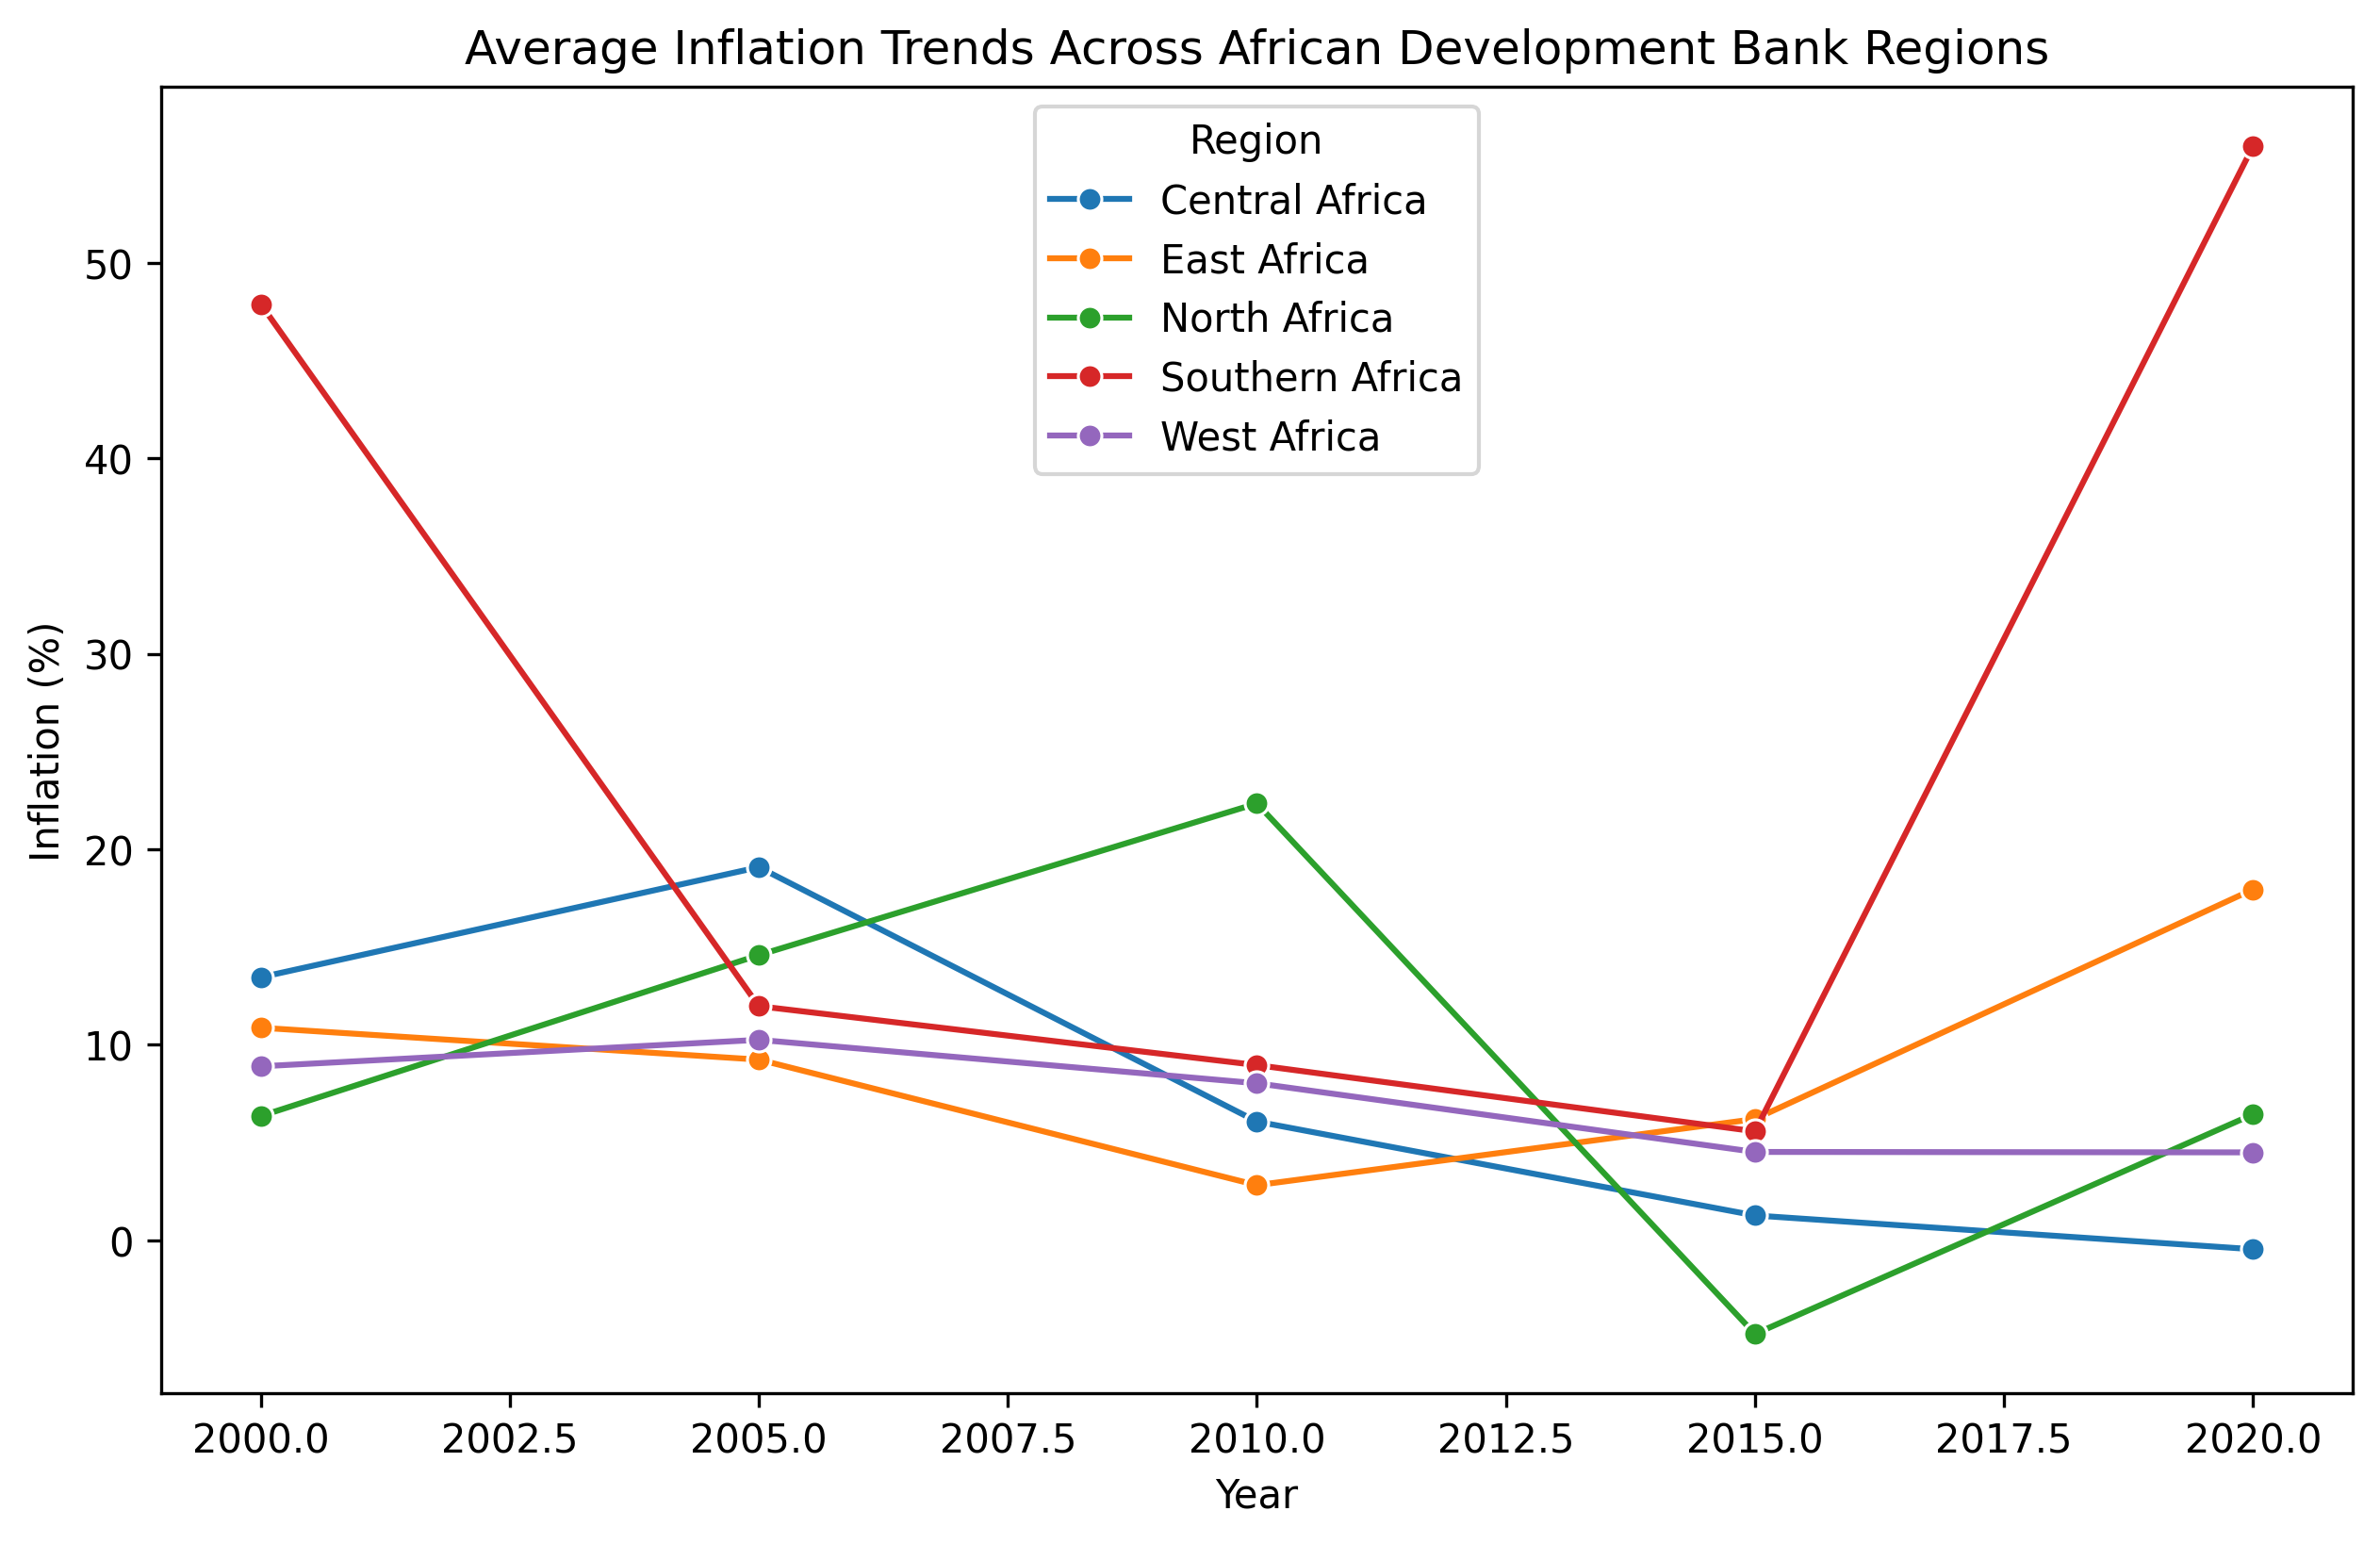

In [31]:
# Plot inflation trends

plt.figure(figsize=(10,6), dpi=300)
sns.lineplot(data=inflation_region, x="Year", y="Inflation", hue="Region", marker="o")
plt.title("Average Inflation Trends Across African Development Bank Regions")
plt.ylabel("Inflation (%)")
plt.xlabel("Year")
plt.legend(title="Region")
plt.savefig("inflation trends.png", bbox_inches="tight")
plt.show()

#### Inflation Trends Insights:

- **Southern Africa:**  
  - 2000: Extremely high inflation (50%) — likely due to ongoing economic instability in Zimbabwe.  
  - 2020: Spike in inflation (57%) — likely impacted by COVID-19 related supply and demand shocks.
  - Implication: Global or regional shocks can have immediate, sharp effects on inflation.
    
- **Central Africa:**  
  - Overall decline from 13% (2000) to 1% (2020) — indicates improving price stability; no major external shocks noted in this period.

- **East Africa:**  
  - 2020: Moderate spike to 18% — possibly influenced by COVID-19 disruptions and regional supply chain pressures.  
  - Other years remain moderate and stable.

- **West Africa:**  
  - Inflation remained relatively stable (5–10%) across all years — consistent with effective regional monetary policies.
  - Implication: Regional collaboration and adherence to disciplined fiscal/monetary policies can help sustain stable inflation.

- **North Africa:**  
  - 2005–2010: High inflation (14–22%) — likely associated with political unrest in some countries during this period.  
  - Post-2010, inflation stabilizes (~4–7.5%), reflecting relative economic stabilization.
  - Implication: Economic planning must consider political risk; contingency plans for supply chain and currency stability may be needed.

***

### c. Scatterplot of GDP vs Unemployment

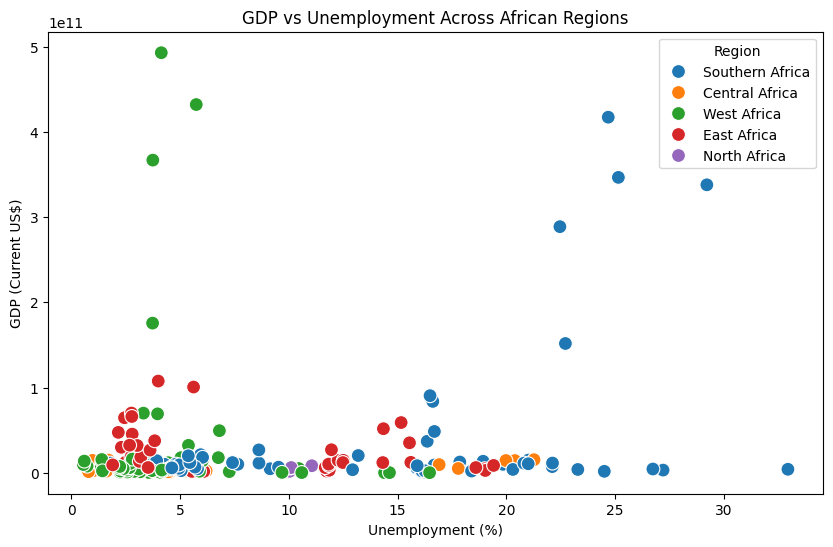

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_final_clean, x="Unemployment", y="GDP", hue="Region", s=100)
plt.title("GDP vs Unemployment Across African Regions")
plt.xlabel("Unemployment (%)")
plt.ylabel("GDP (Current US$)")
plt.legend(title="Region")
plt.show()

#### Identifying Outliers
- For this analysis, countries are considered outliers if their GDP falls in the **top 5%** and Unemployment falls **above 99%**  of all values.
- These outlier countries are labeled directly on the scatterplot to highlight exceptional economic cases for particular years.

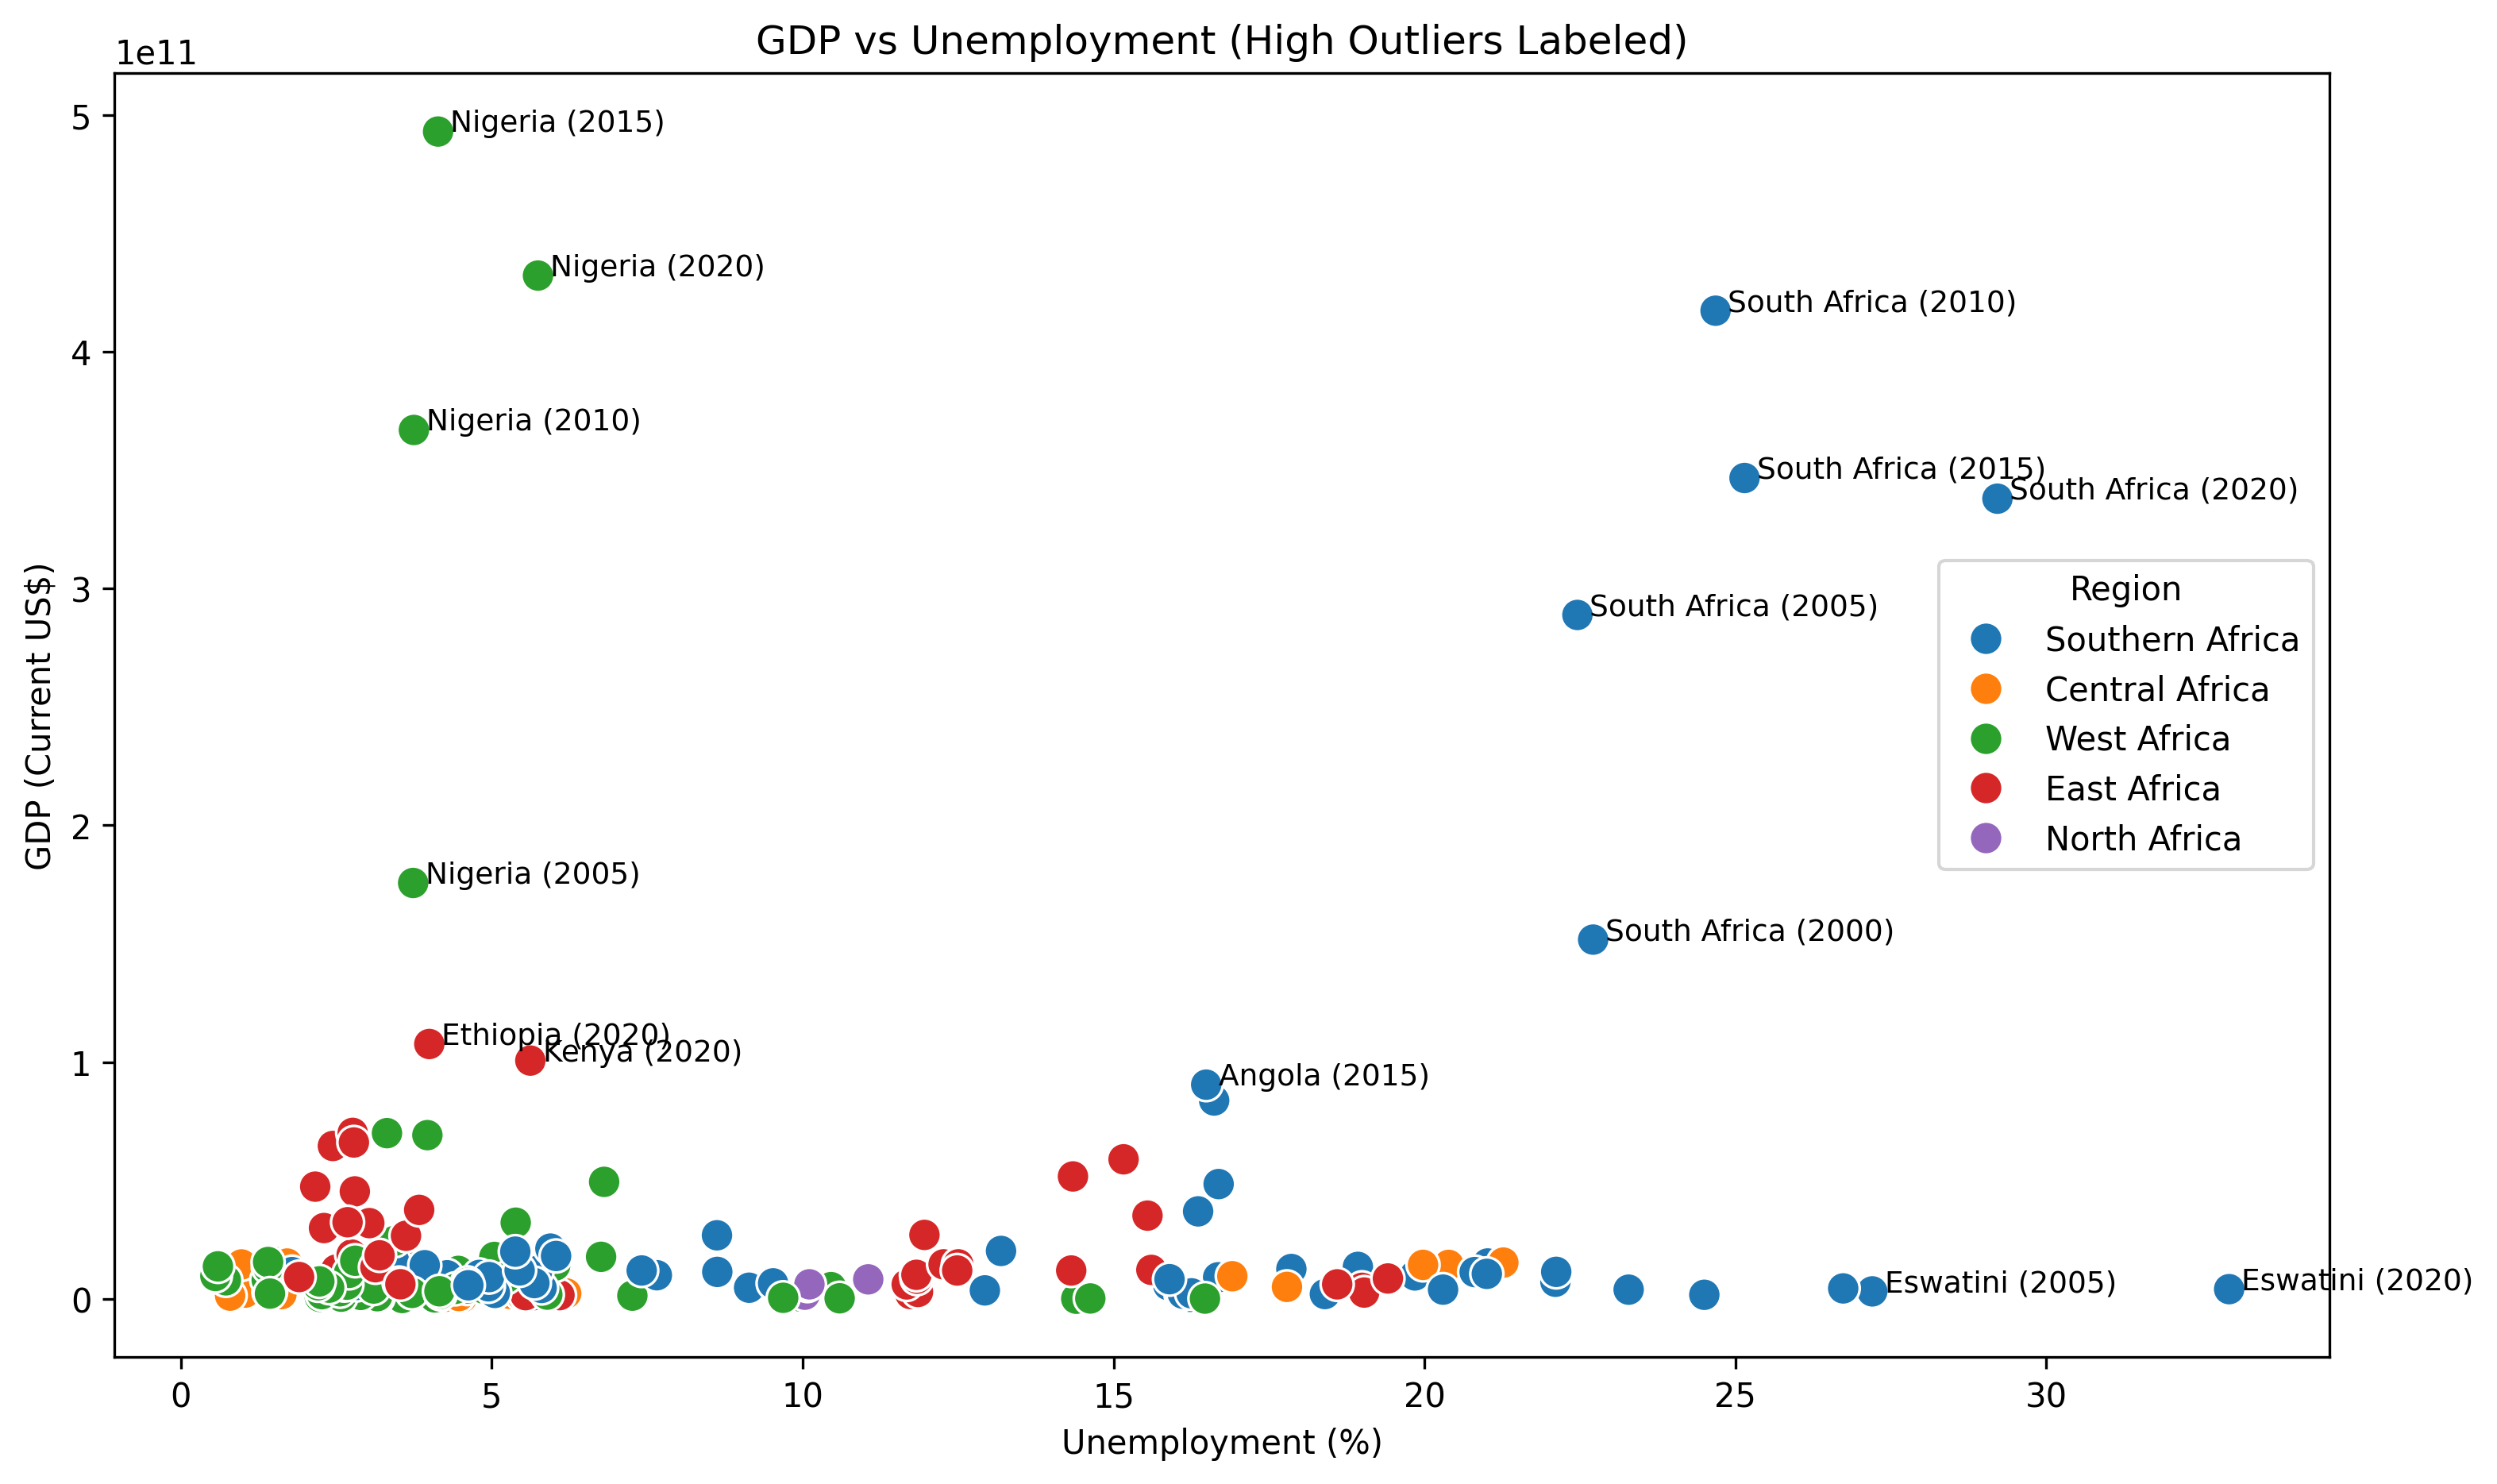

In [33]:

# Drop rows with missing values
df_scatter = df_final_clean.dropna(subset=["GDP", "Unemployment"])

# Define thresholds for **high** outliers (top 5%)
gdp_upper = df_scatter["GDP"].quantile(0.95)
unemp_upper = df_scatter["Unemployment"].quantile(0.99)

plt.figure(figsize=(12,7), dpi=300)

# Scatterplot
sns.scatterplot(data=df_scatter, x="Unemployment", y="GDP", hue="Region", s=100)

# Annotate only high outliers
for i, row in df_scatter.iterrows():
    if row["GDP"] >= gdp_upper or row["Unemployment"] >= unemp_upper:
        plt.text(
            row["Unemployment"] + 0.2,          # x-position slightly offset
            row["GDP"],                          # y-position
            f"{row['Country']} ({int(row['Year'])})",  # label: Country (Year)
            fontsize=9
        )

plt.title("GDP vs Unemployment (High Outliers Labeled)")
plt.xlabel("Unemployment (%)")
plt.ylabel("GDP (Current US$)")
plt.legend(title="Region")
plt.savefig("gdp_vs_unemployment.png", bbox_inches="tight")
plt.show()


#### GDP vs Unemployment Insights

- South Africa shows persistently high unemployment (22–28%) despite moderate GDP growth (1.7–4.2B USD), indicating "growth-without-jobs".
- Nigeria exhibits consistent GDP growth (1.8–5.0B USD) with low unemployment (3–6%), reflecting inclusive growth.
- Angola (2015) had moderate GDP (0.9B USD) with high unemployment (16.5%).
- Ethiopia and Kenya show upward GDP trends (1–1.1B USD) with relatively low unemployment (3–5%).
- Eswatini experiences drastic unemployment rise (27–37%) with GDP near zero.
- Southern Africa tends to have higher unemployment compared to East and West Africa, highlighting regional labor market challenges.
- West Africa unemployment is clustered on the lower side close to 5% with only outlying cases reaching a maximum of 17%
- Central Africa shows GDP trends with clustering around near zero growth, while unemployment clusters are lower than 7% with some outliers in the 16-22% range.
- High GDP does not necessarily imply high unemployment, and vice versa.
***